# ***Phase-Wise Tactical IPL Match Analysis***

## ***Project Overview***

A data analytics project analyzing IPL T20 matches using ball-by-ball data to uncover tactical insights beyond traditional stadium averages. Teams often rely on overall averages and toss luck instead of analyzing how matches evolve across different innings phases.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import streamlit as st 

In [2]:
df = pd.read_csv("C:\\Users\\dhrum\\Documents\\ipl crunch hackathon\\att_0_1778303821_c3a907.csv")
display(df.sample(10))

C:\Users\dhrum\AppData\Local\Temp\ipykernel_17452\3420603443.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Users\\dhrum\\Documents\\ipl crunch hackathon\\att_0_1778303821_c3a907.csv")


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
268483,980937,2016-04-24,2016,Indian Premier League,Saurashtra Cricket Association Stadium,Rajkot,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,...,SK Raina,6,0,6,0,0,0,0,NaN,NaN
87517,1304113,2022-05-19,2022,Indian Premier League,"Wankhede Stadium, Mumbai",Mumbai,Gujarat Titans,Royal Challengers Bangalore,Gujarat Titans,bat,...,HH Pandya,0,0,0,0,0,0,0,NaN,NaN
119367,1426288,2024-05-02,2024,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Rajasthan Royals,Sunrisers Hyderabad,bat,...,YBK Jaiswal,1,0,1,0,0,0,0,NaN,NaN
75147,1304062,2022-04-08,2022,Indian Premier League,"Brabourne Stadium, Mumbai",Mumbai,Punjab Kings,Gujarat Titans,Gujarat Titans,field,...,LS Livingstone,3,0,3,0,0,0,0,NaN,NaN
179040,419148,2010-04-10,2009/10,Indian Premier League,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,CA Pujara,1,0,1,0,0,0,0,NaN,NaN
220609,598008,2013-04-11,2013,Indian Premier League,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,...,AB de Villiers,0,1,1,1,0,0,0,NaN,NaN
236682,729283,2014-04-18,2014,Indian Premier League,Sheikh Zayed Stadium,Abu Dhabi,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,...,BB McCullum,1,0,1,0,0,0,0,NaN,NaN
132461,1473472,2025-04-19,2025,Indian Premier League,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,Delhi Capitals,Gujarat Titans,Gujarat Titans,field,...,AR Patel,0,0,0,0,0,0,0,NaN,NaN
197211,501258,2011-05-15,2011,Indian Premier League,Holkar Cricket Stadium,Indore,Kochi Tuskers Kerala,Rajasthan Royals,Kochi Tuskers Kerala,field,...,SW Tait,0,0,0,0,0,0,0,NaN,NaN
42735,1216493,2020-09-20,2020/21,Indian Premier League,Dubai International Cricket Stadium,NaN,Delhi Capitals,Kings XI Punjab,Kings XI Punjab,field,...,RR Pant,0,0,0,0,0,0,0,NaN,NaN


## ***1. Exploratory Data Analysis (EDA)***

In [3]:
df.shape

(289673, 30)

In [4]:
df.describe()

,match_id,win_by_runs,win_by_wickets,innings,over,ball,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes
count,2.896730e+05,133547.000000,151146.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000
mean,9.654832e+05,30.217766,6.115266,1.482793,9.190563,3.628167,1.285477,0.068184,1.353661,0.039565,0.004277,0.004705,0.019601
std,3.911715e+05,26.530801,1.823510,0.502495,5.680221,1.818353,1.659483,0.342671,1.645469,0.255822,0.068964,0.114363,0.190069
min,3.359820e+05,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483650e+05,11.000000,5.000000,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.082626e+06,22.000000,6.000000,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.304085e+06,41.000000,7.000000,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.529292e+06,146.000000,10.000000,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,5.000000,5.000000,4.000000,5.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 289673 entries, 0 to 289672
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           289673 non-null  int64  
 1   date               289673 non-null  str    
 2   season             289673 non-null  object 
 3   event              289673 non-null  str    
 4   venue              289673 non-null  str    
 5   city               277276 non-null  str    
 6   team1              289673 non-null  str    
 7   team2              289673 non-null  str    
 8   toss_winner        289673 non-null  str    
 9   toss_decision      289673 non-null  str    
 10  winner             289673 non-null  str    
 11  win_by_runs        133547 non-null  float64
 12  win_by_wickets     151146 non-null  float64
 13  player_of_match    288845 non-null  str    
 14  innings            289673 non-null  int64  
 15  batting_team       289673 non-null  str    
 16  over         

In [6]:
df.isnull().sum()

match_id                  0
date                      0
season                    0
event                     0
venue                     0
city                  12397
team1                     0
team2                     0
toss_winner               0
toss_decision             0
winner                    0
win_by_runs          156126
win_by_wickets       138527
player_of_match         828
innings                   0
batting_team              0
over                      0
ball                      0
batter                    0
bowler                    0
non_striker               0
runs_batter               0
runs_extras               0
runs_total                0
extras_wides              0
extras_noballs            0
extras_byes               0
extras_legbyes            0
wicket_kind          275267
wicket_player_out    275267
dtype: int64

In [7]:
df.columns

Index(['match_id', 'date', 'season', 'event', 'venue', 'city', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over',
       'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras',
       'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes',
       'extras_legbyes', 'wicket_kind', 'wicket_player_out'],
      dtype='str')

### ***2. Do teams that win the toss actually win more matches?***

Total percentage of teams WINNING when they chose to bat = 45.62
Total percentage of teams WINNING when they chose to bowl = 52.56

Total percentage of teams LOSING when they chose to bat = 54.38
Total percentage of teams LOSING when they chose to bowl = 47.44

Toss Winners winning the matches = 50.20
Toss Losers winning the matches = 49.80


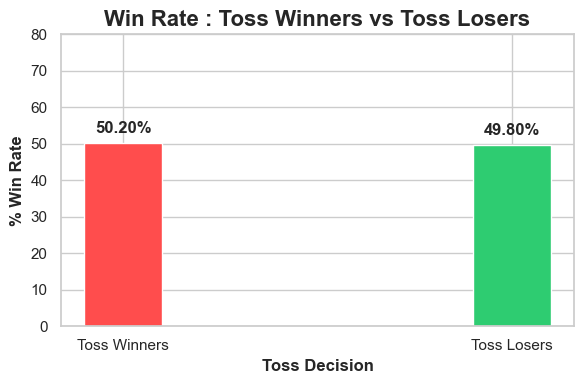

In [8]:
# total number of teams that chose to bat or bowl  
total_bats = df[df['toss_decision']=='bat'].shape[0]
total_bowls = df[df['toss_decision']=='field'].shape[0]

# total number of teams winning respectively when they choose to bat or field 
total_bats_winners = df[(df['toss_decision'] == 'bat') & (df['toss_winner'] == df['winner'])].shape[0]
total_bowl_winners = df[(df['toss_decision'] == 'field') & (df['toss_winner'] == df['winner'])].shape[0]

# total number of teams losing respectively when they choose to bat or field 
total_bats_losers = df[(df['toss_decision'] == 'bat') & (df['toss_winner'] != df['winner'])].shape[0]
total_bowl_losers = df[(df['toss_decision'] == 'field') & (df['toss_winner'] != df['winner'])].shape[0]

# find the toss winners and their corresponding match winners - both winning the toss and the match 
toss_match_winners = df[df['toss_winner'] == df['winner']].shape[0]
total_matches = df['winner'].count()

toss_winner_win_rate = toss_match_winners*100/total_matches
toss_loser_lose_rate = 100 - toss_winner_win_rate

print(f"Total percentage of teams WINNING when they chose to bat = {(total_bats_winners*100/total_bats):.2f}")
print(f"Total percentage of teams WINNING when they chose to bowl = {(total_bowl_winners*100/total_bowls):.2f}\n")

print(f"Total percentage of teams LOSING when they chose to bat = {(total_bats_losers*100/total_bats):.2f}")
print(f"Total percentage of teams LOSING when they chose to bowl = {(total_bowl_losers*100/total_bowls):.2f}\n")

print(f"Toss Winners winning the matches = {toss_winner_win_rate:.2f}")
print(f"Toss Losers winning the matches = {toss_loser_lose_rate:.2f}")

# plotting it out 
plt.figure(figsize=(6,4))
sns.set_theme(style='whitegrid')

categories = ['Toss Winners', 'Toss Losers']
vals = [toss_winner_win_rate, toss_loser_lose_rate]
colors = ['#ff4d4d', '#2ecc71']

bars = plt.bar(categories, vals, color=colors,width=0.2)
plt.bar_label(bars, fmt='%.2f%%', fontweight='bold', fontsize=12, padding=5)
plt.title('Win Rate : Toss Winners vs Toss Losers', fontsize=16, fontweight='bold')
plt.xlabel('Toss Decision', fontsize=12, fontweight='bold')
plt.ylabel('% Win Rate', fontsize=12, fontweight='bold')
plt.ylim(0,80)
plt.tight_layout()
plt.show()

### ***3. Which phase impacts victory the most — Powerplay, Middle Overs, or Death Overs?***

In [9]:
def get_phase(over):
    if over < 6: return "Powerplay"
    elif over < 15: return "Middle Overs"
    else: return "Death Over"

df["phase_over"] = df["over"].apply(get_phase)
df['is_wicket'] = df['wicket_kind'].notna().astype(int)

# calculate the total runs and then do the same for the match phases as well and then merge them 
total_scores_runs = df.groupby(["match_id", "innings", "venue"])["runs_total"].sum().reset_index()
phase_scores_runs = df.groupby(['match_id', 'innings', 'phase_over'])['runs_total'].sum().unstack().reset_index()

merged_stats = pd.merge(phase_scores_runs, total_scores_runs, on=["match_id", "innings"])

phase_cols = ['Powerplay', 'Middle Overs', 'Death Over']
for col in phase_cols:
    if col not in merged_stats.columns:
        merged_stats[col] = 0
    else:
        merged_stats[col] = merged_stats[col].fillna(0)

# calculate the contributions of run rate in each of the phases
merged_stats['powerplay_pct'] = ((merged_stats['Powerplay'] / merged_stats['runs_total']) * 100).round(2)
merged_stats['middle_overs_pct'] = ((merged_stats['Middle Overs'] / merged_stats['runs_total']) * 100).round(2)
merged_stats['death_overs_pct'] = ((merged_stats['Death Over'] / merged_stats['runs_total']) * 100).round(2)

inn1_scores = merged_stats[merged_stats['innings'] == 1][['match_id', 'runs_total']].rename(columns={'runs_total': 'inn1_total'})
inn2_scores = merged_stats[merged_stats['innings'] == 2][['match_id', 'runs_total']].rename(columns={'runs_total': 'inn2_total'})

merged_stats = pd.merge(merged_stats, inn1_scores, on='match_id', how='left')
merged_stats = pd.merge(merged_stats, inn2_scores, on='match_id', how='left')

def decision(row):
    if pd.isna(row['inn1_total']) or pd.isna(row['inn2_total']):
        return 'Tie'    
    if row['innings'] == 1:
        return 'Won' if row['inn1_total'] > row['inn2_total'] else 'Lost'
    else:
        return 'Won' if row['inn2_total'] > row['inn1_total'] else 'Lost'

merged_stats['outcome'] = merged_stats.apply(decision, axis=1)

clean_df = merged_stats[merged_stats['outcome'].isin(['Won', 'Lost'])]
display(clean_df.head(10))

final_summary = clean_df.groupby('outcome')[['powerplay_pct', 'middle_overs_pct', 'death_overs_pct']].mean()
display(final_summary.round(2))

,match_id,innings,Death Over,Middle Overs,Powerplay,venue,runs_total,powerplay_pct,middle_overs_pct,death_overs_pct,inn1_total,inn2_total,outcome
0,335982,1,68.0,93.0,61.0,M Chinnaswamy Stadium,222,27.48,41.89,30.63,222,82.0,Won
1,335982,2,1.0,55.0,26.0,M Chinnaswamy Stadium,82,31.71,67.07,1.22,222,82.0,Lost
2,335983,1,79.0,108.0,53.0,"Punjab Cricket Association Stadium, Mohali",240,22.08,45.00,32.92,240,207.0,Won
3,335983,2,42.0,102.0,63.0,"Punjab Cricket Association Stadium, Mohali",207,30.43,49.28,20.29,240,207.0,Lost
4,335984,1,33.0,56.0,40.0,Feroz Shah Kotla,129,31.01,43.41,25.58,129,132.0,Lost
5,335984,2,4.0,73.0,55.0,Feroz Shah Kotla,132,41.67,55.30,3.03,129,132.0,Won
6,335985,1,60.0,58.0,47.0,Wankhede Stadium,165,28.48,35.15,36.36,165,166.0,Lost
7,335985,2,48.0,78.0,40.0,Wankhede Stadium,166,24.10,46.99,28.92,165,166.0,Won
8,335986,1,33.0,38.0,39.0,Eden Gardens,110,35.45,34.55,30.00,110,112.0,Lost
9,335986,2,31.0,55.0,26.0,Eden Gardens,112,23.21,49.11,27.68,110,112.0,Won


,powerplay_pct,middle_overs_pct,death_overs_pct
outcome,,,
Lost,32.31,41.84,25.85
Won,30.85,44.02,25.13


,outcome,Match Phase,Average Percentage of Total Score
0,Lost,Powerplay (Overs 1-6),32.307567
1,Won,Powerplay (Overs 1-6),30.853503
2,Lost,Middle Overs (Overs 7-15),41.838471
3,Won,Middle Overs (Overs 7-15),44.020619
4,Lost,Death Overs (Overs 16-20),25.854136
5,Won,Death Overs (Overs 16-20),25.125761


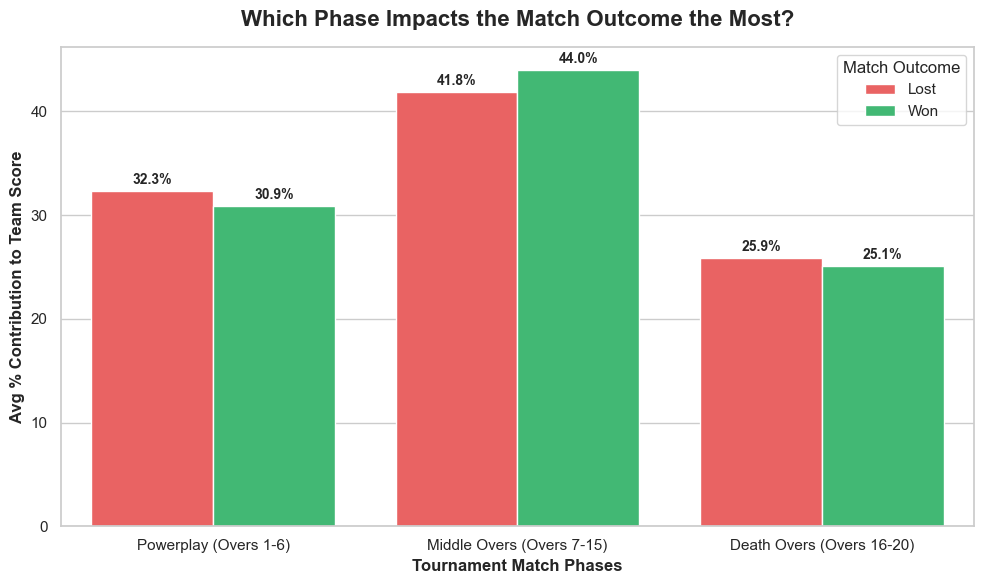

In [10]:
plot_data = final_summary.reset_index()

# widen the dataframe to get a better idea
melted_data = pd.melt(plot_data, id_vars=['outcome'], value_vars=['powerplay_pct', 'middle_overs_pct', 'death_overs_pct'],var_name='Match Phase', value_name='Average Percentage of Total Score')

melted_data['Match Phase'] = melted_data['Match Phase'].replace({'powerplay_pct': 'Powerplay (Overs 1-6)','middle_overs_pct': 'Middle Overs (Overs 7-15)','death_overs_pct': 'Death Overs (Overs 16-20)'})
display(melted_data)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=melted_data,x='Match Phase',y='Average Percentage of Total Score',hue='outcome',palette=['#ff4d4d', '#2ecc71'])  

plt.title('Which Phase Impacts the Match Outcome the Most?', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tournament Match Phases', fontsize=12, fontweight='bold')
plt.ylabel('Avg % Contribution to Team Score', fontsize=12, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')

plt.legend(title='Match Outcome', loc='upper right')
plt.tight_layout()
plt.show()

Clearly, we can say that **middle over** phase, has the most impact on the match, where it is statistically vital for the teams to place their strong batsmen and strong bowlers during these phases

## ***4. Who are the top batters and bowlers across seasons?***

In [11]:
df.rename(columns={'phase_over': 'match_phase'}, inplace=True)

In [12]:
# average run rate per phase = total runs scored in the phase*6* / total overs played in that phase 
venue  = df.groupby(['match_phase', 'venue']).agg(phase_runs=('runs_total','sum'), phase_balls=('ball','count'), phase_wickets=('is_wicket','sum')).reset_index()

venue['avg_run_rate'] = (venue['phase_runs'] * 6 / venue['phase_balls']).round(2)
venue['avg_bowl_rate'] = (venue['phase_runs'] / venue['phase_wickets']).round(2)

venue_batters = venue[['match_phase','venue','phase_runs','phase_balls','avg_run_rate']]

venue_bowlers = venue[['match_phase','venue','phase_runs','phase_wickets','phase_balls','avg_bowl_rate']]
venue_bowlers = venue_bowlers[(venue_bowlers['phase_balls'] >= 300) & (venue_bowlers['match_phase'] == "Powerplay")]

display(venue_batters.sort_values(by='avg_run_rate', ascending=False).head(5)) 
display(venue_bowlers.sort_values(by='avg_bowl_rate', ascending=True).head(5))

,match_phase,venue,phase_runs,phase_balls,avg_run_rate
148,Powerplay,Maharaja Yadavindra Singh International Cricke...,725,378,11.51
19,Death Over,"Himachal Pradesh Cricket Association Stadium, ...",576,303,11.41
15,Death Over,"Eden Gardens, Kolkata",2554,1395,10.98
25,Death Over,M.Chinnaswamy Stadium,1513,845,10.74
20,Death Over,Holkar Cricket Stadium,674,378,10.70


,match_phase,venue,phase_runs,phase_wickets,phase_balls,avg_bowl_rate
152,Powerplay,Nehru Stadium,398,20,380,19.90
154,Powerplay,Newlands,594,27,537,22.00
144,Powerplay,MA Chidambaram Stadium,781,34,664,22.97
127,Powerplay,Dr DY Patil Sports Academy,1439,57,1281,25.25
167,Powerplay,Shaheed Veer Narayan Singh International Stadium,460,18,449,25.56


In [13]:
# come up with some statistics over how many overs / balls each of the batters have faced, how many runs they have scored and what their strike rates are in each of the 3 phases of the match.
# batters impact performance lies in the death overs phase while bowlers impact performance lies in powerplay phase. so we calculate batting and bowling strike rates in these two phases specifically, to determine top batters and bowlers

df_batters = df.groupby(['season','match_phase','batter']).agg(total_runs=('runs_batter','sum'), total_balls=('ball','count')).reset_index()
df_batters['batter_strike_rate'] = ((df_batters['total_runs'] / df_batters['total_balls']) * 100).round(2)
df_batters_filtered = df_batters[df_batters['total_balls'] >= 30]  # Filter to ensure we only consider batters with a minimum number of balls faced for reliability

df_bowlers = df.groupby(['season', 'match_phase', 'bowler']).agg(total_wickets=('is_wicket','sum'), total_balls=('ball','count')).reset_index()
df_bowlers['bowler_strike_rate'] = (df_bowlers['total_balls'] / df_bowlers['total_wickets']).round(2)
df_bowlers_filtered = df_bowlers[(df_bowlers['total_balls'] >= 30) & (df_bowlers['total_wickets'] >= 3)]  # Filter to ensure we only consider bowlers with a minimum number of balls bowled for reliability

death_batters  = df_batters_filtered[df_batters_filtered['match_phase'] == "Death Over"].sort_values(by='batter_strike_rate', ascending=False).head(5)
powerplay_bowlers = df_bowlers_filtered[df_bowlers_filtered['match_phase'] == "Powerplay"].sort_values(by='bowler_strike_rate', ascending=True).head(5)

display(death_batters[['season','batter','batter_strike_rate']])
display(powerplay_bowlers[['season','bowler','bowler_strike_rate']])

,season,batter,batter_strike_rate
2345,2019,AD Russell,288.14
3607,2024,T Stubbs,257.14
4202,2026,Tilak Varma,255.26
5697,2019,AB de Villiers,251.35
4106,2026,C Connolly,250.00


,season,bowler,bowler_strike_rate
5294,2019,S Gopal,6.0
4184,2007/08,YK Pathan,7.5
3106,2023,PWH de Silva,7.5
1297,2015,MC Henriques,8.0
435,2012,DS Kulkarni,8.0


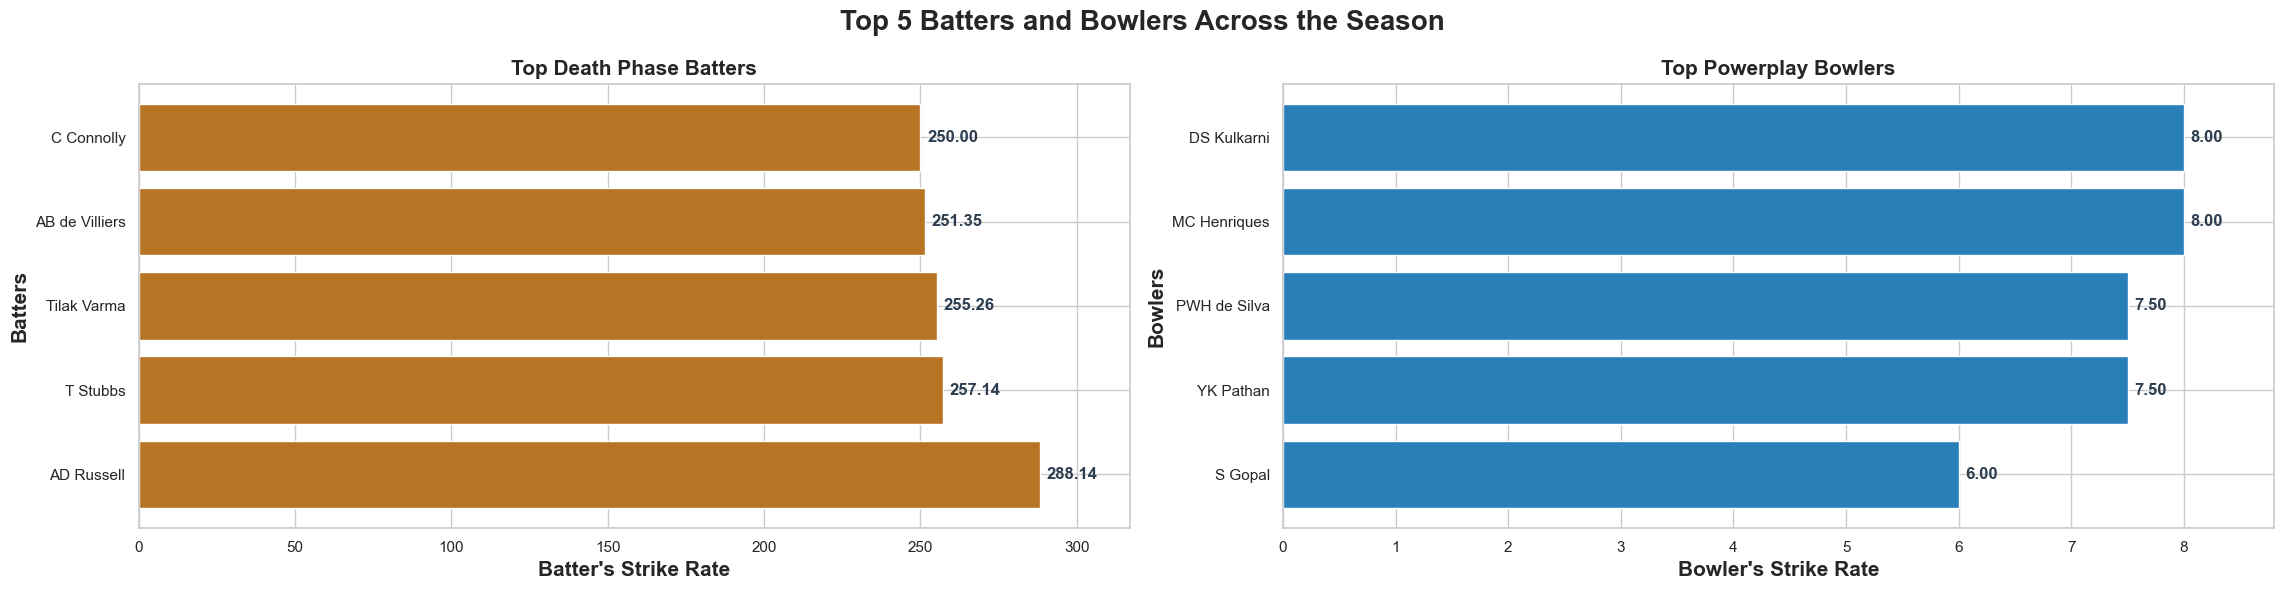

In [14]:
# horizontal bar charts for bowlers and batters  
sns.set_theme(style="whitegrid")
fig,ax = plt.subplots(1,2,figsize=(23,6))

bars_batters = ax[0].barh(death_batters['batter'], death_batters['batter_strike_rate'], color="#b67424")
ax[0].set_title("Top Death Phase Batters", fontsize=15, fontweight='bold')
ax[0].set_xlabel("Batter's Strike Rate", fontsize=15, fontweight="bold")
ax[0].set_ylabel("Batters", fontsize=15, fontweight="bold")
ax[0].bar_label(bars_batters, fmt='%.2f', padding=5, fontsize=12, fontweight='bold', color='#2c3e50') # used for annotations on the bar
ax[0].set_xlim(0, max(death_batters['batter_strike_rate']) * 1.10) # extending for more breathing room 

bars_bowlers = ax[1].barh(powerplay_bowlers['bowler'], powerplay_bowlers['bowler_strike_rate'], color="#2980b9")
ax[1].set_title("Top Powerplay Bowlers", fontsize=15, fontweight="bold")
ax[1].set_xlabel("Bowler's Strike Rate", fontsize=15, fontweight="bold")
ax[1].set_ylabel("Bowlers", fontsize=15, fontweight="bold")
ax[1].bar_label(bars_bowlers, fmt='%.2f', padding=5, fontsize=12, fontweight='bold', color='#2c3e50') # used for annotations on the bar 
ax[1].set_xlim(0, max(powerplay_bowlers['bowler_strike_rate']) * 1.10) # extending for more breathing room 

plt.suptitle("Top 5 Batters and Bowlers Across the Season", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

## ***5. Venue Specific Phase Analysis*** 

Stadium_name,Eden Gardens,Feroz Shah Kotla,M Chinnaswamy Stadium,Wankhede Stadium
match_phase,,,,
Powerplay,7.44,7.59,7.23,7.30
Middle Overs,7.54,7.60,7.86,7.62
Death Over,9.29,9.06,10.18,9.63


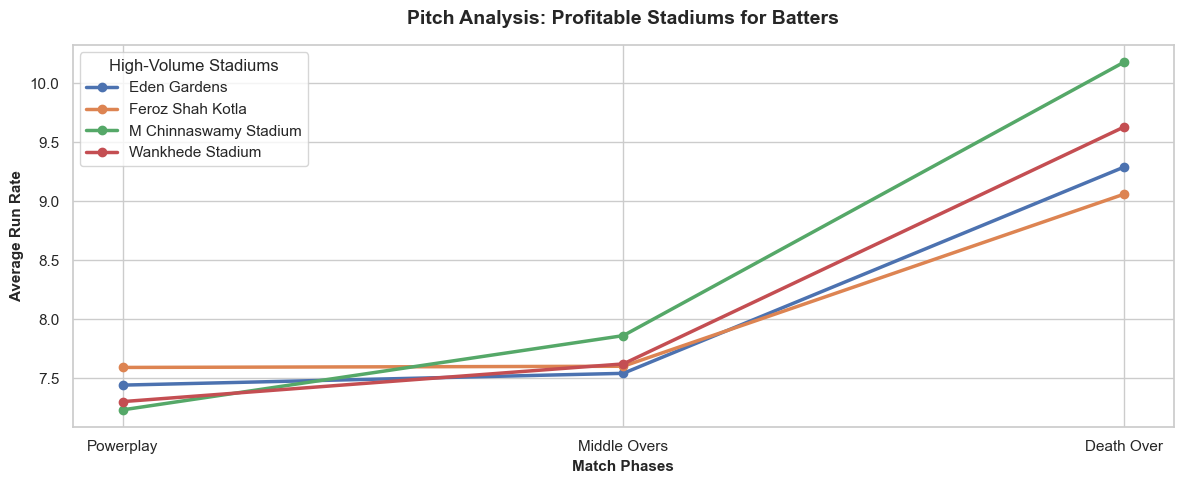

In [ ]:
# Top 5 stadiums with the highest total ball count 
venue_volumes = venue_batters.groupby('venue')['phase_balls'].sum().reset_index()
# Finding out the stadiums where the teams (batters and bowlers) have played the most suggesting higher a volume which is better for statistical analysis
top_5_venues = venue_volumes.sort_values(by='phase_balls', ascending=False).head(5)['venue'].tolist()

# Finding the best pitches for the batters
df_top_5 = venue_batters[venue_batters['venue'].isin(top_5_venues)].copy()
df_top_5['Stadium_name'] = df_top_5['venue'].apply(lambda x: x.split(',')[0])
df_top_5 = df_top_5.drop_duplicates(subset=['Stadium_name','match_phase']) # dropping duplicates to avoid errors while pivoting the dataframe

# Define timeline 
phase_order = ['Powerplay', 'Middle Overs', 'Death Over'] 
pivot_df = df_top_5.pivot(index='Stadium_name',columns='match_phase',values='avg_run_rate') # pivot turns the phases into columns of run rates during those phases
pivot_df = pivot_df[phase_order]
display(pivot_df.T) # .T is a function used to transform the whole dataframe changing its index to columns and its header row to index

# make line chart
plt.figure(figsize=(12, 5))
plt.plot(pivot_df.T ,marker='o', linewidth=2.5)
plt.title('Pitch Analysis: Profitable Stadiums for Batters', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Match Phases', fontsize=11, fontweight='bold')
plt.ylabel('Average Run Rate', fontsize=11, fontweight='bold')
plt.legend(pivot_df.index, title='High-Volume Stadiums', loc='upper left')
plt.tight_layout()
plt.show()

Some stadiums naturally make batting easier and lead to higher scoring rates. By identifying these batter-friendly venues, teams can understand where aggressive batting is more rewarding and where playing too cautiously may waste an advantage.

Instead of relying on slow starts or conservative anchor roles, teams can adapt their strategy to attack earlier, take more scoring risks, and fully use the conditions in their favor. This helps captains and coaches make smarter decisions about batting order, intent, and overall match tempo based on the venue itself.

In [16]:
# proving out statistics is right 
df_top_5_bowlers = venue[venue['venue'].isin(top_5_venues)].copy()
df_top_5_bowlers['Stadium_name'] = df_top_5_bowlers['venue'].apply(lambda x: x.split(',')[0])
df_top_5_bowlers = df_top_5_bowlers.drop_duplicates(subset=['Stadium_name','match_phase'])

pivot_df2 = df_top_5_bowlers.pivot(index='Stadium_name',columns='match_phase' ,values='avg_bowl_rate')
pivot_df2 = pivot_df2[phase_order]
display(pivot_df2.T)

Stadium_name,Eden Gardens,Feroz Shah Kotla,M Chinnaswamy Stadium,Wankhede Stadium
match_phase,,,,
Powerplay,32.68,30.79,31.02,30.76
Middle Overs,28.87,31.45,31.91,30.06
Death Over,20.47,18.30,19.95,19.31


 Our earlier assumption that these stadiums have been an absolute batting paradise is proven to be completely correct, because the bowlers have higher bowling rates in these pitches, meaning for every 30 runs a wicket is taken, which weakens down the defense for the bowling team when its their turn to bat. 

stadium_name,Dr DY Patil Sports Academy,MA Chidambaram Stadium,Nehru Stadium,Newlands,Shaheed Veer Narayan Singh International Stadium
match_phase,,,,,
Powerplay,25.25,22.97,19.90,22.00,25.56
Middle Overs,23.88,26.35,37.35,20.54,29.92
Death Over,17.80,28.00,13.20,15.28,31.35


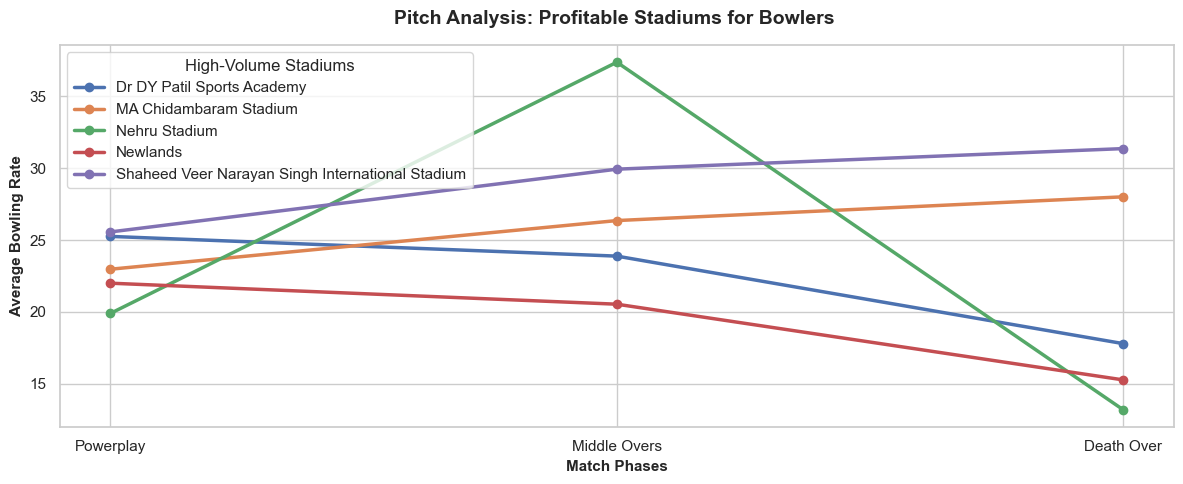

In [17]:
# finding the best pitches for the bowlers as well
top_bowling_venues = venue_bowlers.sort_values(by='avg_bowl_rate', ascending=True).head(5)['venue'].tolist() 
df_top_5_bowlers2 = venue[venue['venue'].isin(top_bowling_venues)].copy()
df_top_5_bowlers2['stadium_name'] = df_top_5_bowlers2['venue'].apply(lambda x:x.split(',')[0])
df_top_5_bowlers2.drop_duplicates(subset=['stadium_name','match_phase'], inplace=True)

pivot_df3 = df_top_5_bowlers2.pivot(index='stadium_name', columns='match_phase', values='avg_bowl_rate')
pivot_df3 = pivot_df3[phase_order]
display(pivot_df3.T)

plt.figure(figsize=(12, 5))
plt.plot(pivot_df3.T ,marker='o', linewidth=2.5)
plt.title('Pitch Analysis: Profitable Stadiums for Bowlers ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Match Phases', fontsize=11, fontweight='bold')
plt.ylabel('Average Bowling Rate', fontsize=11, fontweight='bold')
plt.legend(pivot_df3.index, title='High-Volume Stadiums', loc='upper left')
plt.tight_layout()
plt.show()

**A Special Case : The Nehru Stadium**, looking at the Nehru Stadium the bowling rate spikes at first and then drops massively, during the middle 8-9 overs a massive spike to around 37.5 suggests that the batters spend most of their time stuck, they can't find boundaries, so they rotate around singles and doubles, which results in them entering the death overs in complete desperation. 

**DY Patil & Newlands** stadiums suggest that batters can score decent during the powerplay phase indicating that these fields are much larger, and the suggesting massive spike down in the bowling rate during the death overs suggest that when the fielders are spread out it becomes a graveyard for the batters as they are forced to hit longer shots. 

## ***6. Wicket Impact On Run Rate***

In [18]:
df.sample(10)

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out,match_phase,is_wicket
85114,1304103,2022-05-10,2022,Indian Premier League,"Maharashtra Cricket Association Stadium, Pune",Pune,Gujarat Titans,Lucknow Super Giants,Gujarat Titans,bat,...,0,1,0,0,0,0,NaN,NaN,Middle Overs,0
189223,501224,2011-04-24,2011,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Deccan Chargers,Mumbai Indians,Deccan Chargers,field,...,0,1,0,0,0,0,NaN,NaN,Death Over,0
239809,729309,2014-04-27,2014,Indian Premier League,Sharjah Cricket Stadium,NaN,Delhi Daredevils,Mumbai Indians,Mumbai Indians,bat,...,0,4,0,0,0,0,NaN,NaN,Death Over,0
166994,392232,2009-05-19,2009,Indian Premier League,New Wanderers Stadium,Johannesburg,Royal Challengers Bangalore,Delhi Daredevils,Delhi Daredevils,bat,...,0,6,0,0,0,0,NaN,NaN,Death Over,0
153619,336034,2008-05-03,2007/08,Indian Premier League,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,Deccan Chargers,Deccan Chargers,field,...,0,0,0,0,0,0,NaN,NaN,Middle Overs,0
273887,980983,2016-05-12,2016,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Delhi Daredevils,Delhi Daredevils,field,...,0,1,0,0,0,0,NaN,NaN,Powerplay,0
253793,829731,2015-04-18,2015,Indian Premier League,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Visakhapatnam,Sunrisers Hyderabad,Delhi Daredevils,Delhi Daredevils,bat,...,1,1,0,0,0,1,NaN,NaN,Powerplay,0
191111,501232,2011-04-29,2011,Indian Premier League,M Chinnaswamy Stadium,Bangalore,Royal Challengers Bangalore,Pune Warriors,Pune Warriors,field,...,0,1,0,0,0,0,NaN,NaN,Middle Overs,0
121116,1426296,2024-05-09,2024,Indian Premier League,"Himachal Pradesh Cricket Association Stadium, ...",Dharamsala,Royal Challengers Bengaluru,Punjab Kings,Punjab Kings,field,...,0,6,0,0,0,0,NaN,NaN,Death Over,0
108349,1422123,2024-03-24,2024,Indian Premier League,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,Gujarat Titans,Mumbai Indians,Mumbai Indians,field,...,0,0,0,0,0,0,NaN,NaN,Powerplay,0


In [ ]:
# Identify what tells us a wicket fell
df['wicket_taken'] = df['wicket_player_out'].notna().astype(int)

# List to store the actual runs scored after wickets
runs_after_wickets = []
window_size = 12  # We want to check the next 2 overs (12 balls)

# Loop through the data to inspect the balls after a wicket
for i in range(len(df) - window_size):
    if df.iloc[i]['wicket_taken'] == 1:
        
        # Grab the rows for the next 12 balls
        current_match = df.iloc[i]['match_id']
        next_balls = df.iloc[i+1 : i+1+window_size]
        
        # Make sure these next balls belong to the SAME match and SAME innings
        same_innings_balls = next_balls[next_balls['match_id'] == current_match]
        
        # Collect the runs scored in this post-wicket panic window
        for run in same_innings_balls['runs_total']:
            runs_after_wickets.append(run)

# Calculate the averages
import numpy as np

normal_pace = df['runs_total'].mean() * 6
panic_pace = np.mean(runs_after_wickets) * 6

print(f"Normal Scoring Pace: {normal_pace:.2f} runs/over")
print(f"Scoring Pace in the {window_size} balls after a wicket: {panic_pace:.2f} runs/over")

Normal Scoring Pace: 8.12 runs/over
Scoring Pace in the 12 balls after a wicket: 7.24 runs/over


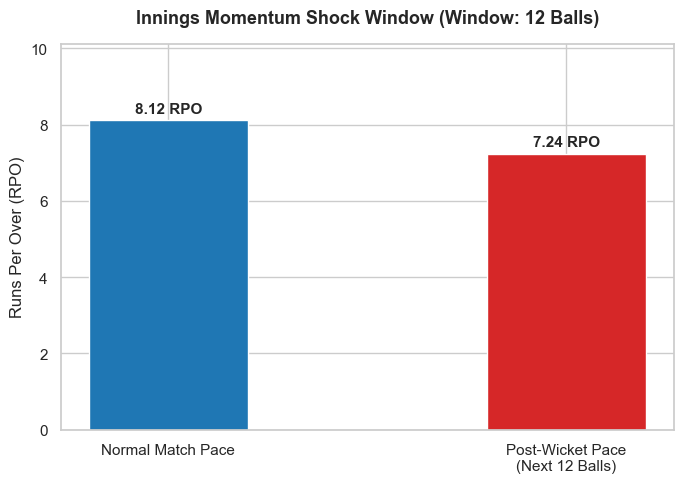

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

categories = ['Normal Match Pace', f'Post-Wicket Pace\n(Next {window_size} Balls)']
paces = [normal_pace, panic_pace]

plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

colors = ['#1f77b4', '#d62728'] 
bars = plt.bar(categories, paces, color=colors, width=0.4)
plt.bar_label(bars, fmt='%.2f RPO', padding=3, weight='bold', fontsize=11)

plt.ylabel("Runs Per Over (RPO)", fontsize=12)
plt.title(f"Innings Momentum Shock Window (Window: {window_size} Balls)", fontsize=13, pad=15, weight='bold')
plt.ylim(0, max(paces) + 2)
plt.tight_layout()
plt.show()

### ***7. Choke Hold Metric (In which phase the bowlers bowl the most dot balls?)*** 

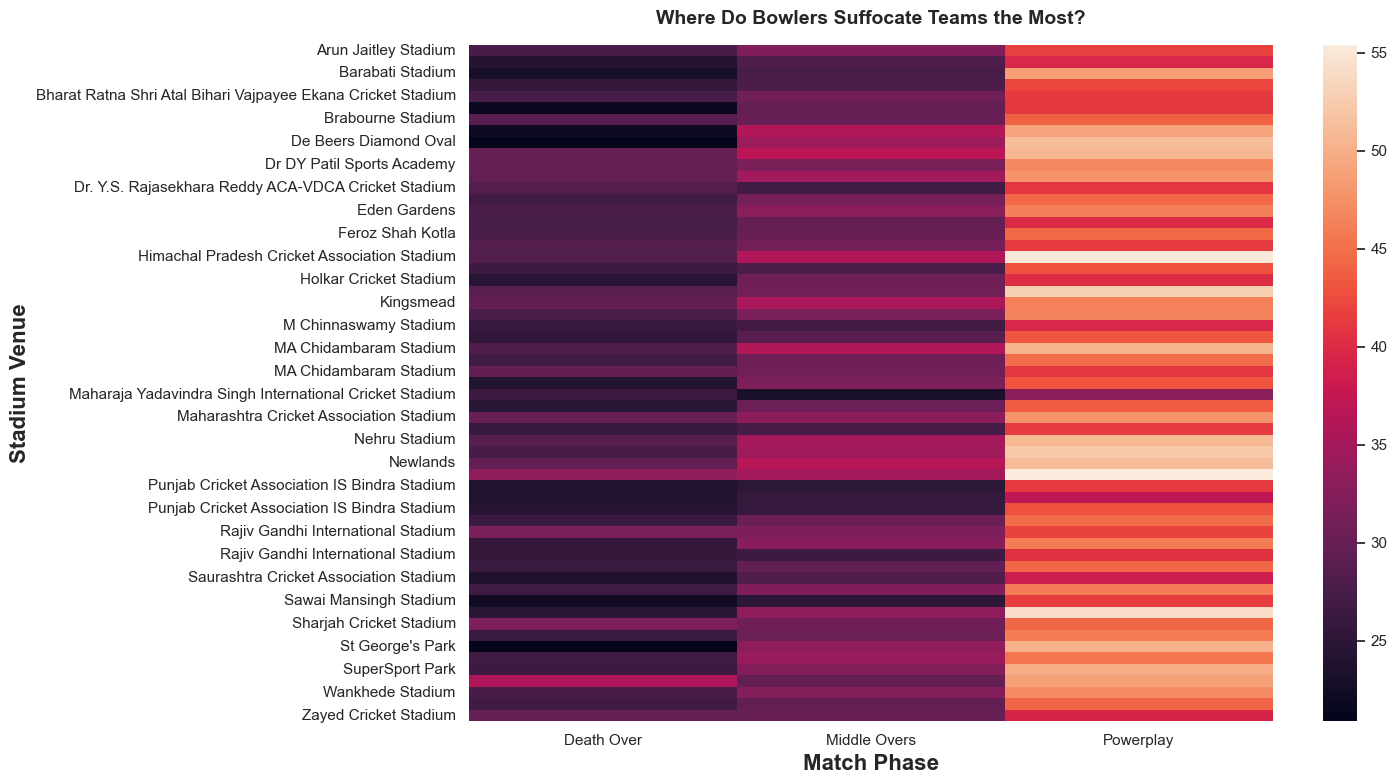

In [20]:
# count total balls in each of the match phases and do the same for the dot balls and then calculate their % 
venue_phase_totals = df.groupby(['venue', 'match_phase']).size()
venue_phase_dots = df[df['runs_total'] == 0].groupby(['venue', 'match_phase']).size()
venue_dot_percentages = (venue_phase_dots / venue_phase_totals * 100).fillna(0)

# avoid errors by filling in missing data wiwth 0 
venue_analysis_df = venue_dot_percentages.unstack().fillna(0).reset_index()

venue_analysis_df['Stadium Name'] = venue_analysis_df['venue'].apply(lambda x: x.split(',')[0])
heatmap_data = venue_analysis_df.set_index('Stadium Name').drop(columns=['venue'])

plt.subplots(figsize=(15, 8))
sns.heatmap(heatmap_data)
plt.title("Where Do Bowlers Suffocate Teams the Most?", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Match Phase", fontweight='bold', fontsize=16)
plt.ylabel("Stadium Venue", fontweight='bold', fontsize=16)
plt.tight_layout()